In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Predicted to True Time Correlation

In [2]:
def plot_correlation(results_path, title):
    results = pd.read_csv(results_path)
    true_times = results["true_interval"].tolist()
    pred_times = results["pred_interval"].tolist()
    true_times = np.array(true_times)
    pred_times = np.array(pred_times)

    # Pearson and Spearman correlation
    r, p = pearsonr(true_times, pred_times)
    print("Pearson r:", round(r, 3))
    print("p-value:", p)

    r, p = spearmanr(true_times, pred_times)
    print("Spearman r:", round(r, 3))
    print("p-value:", p)
    
    # Correlation graph
    plt.figure(figsize=(6,6))
    plt.scatter(true_times, pred_times, alpha=0.5)

    # perfect correlation line
    min_t = min(true_times.min(), pred_times.min())
    max_t = max(true_times.max(), pred_times.max())

    plt.plot([min_t, max_t], [min_t, max_t], "r--")

    plt.xlabel("True time interval (sec)")
    plt.ylabel("Predicted time interval (sec)")
    plt.title(title)

    plt.grid(True)
    plt.show()

    # Error distribution graph
    errors = pred_times - true_times

    plt.figure()
    plt.hist(errors, bins=50)
    plt.xlabel("Prediction error (sec)")
    plt.ylabel("Count")
    plt.title("Error distribution")
    plt.show()
    
    # Calculate Spearman correlation

### DeepTimeEstimator

Pearson r: 0.766
p-value: 1.580924986634959e-80
Spearman r: 0.741
p-value: 7.154966502947588e-73


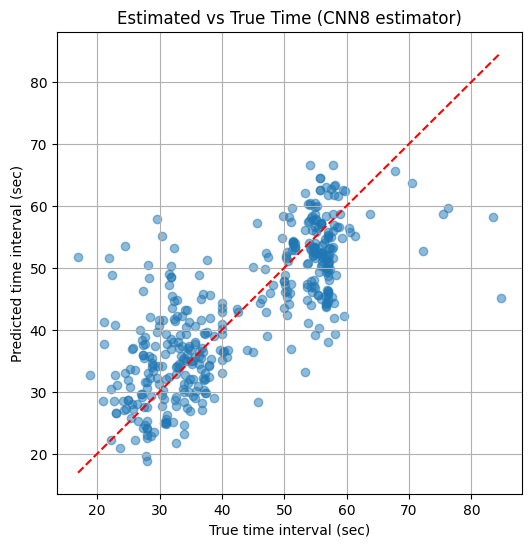

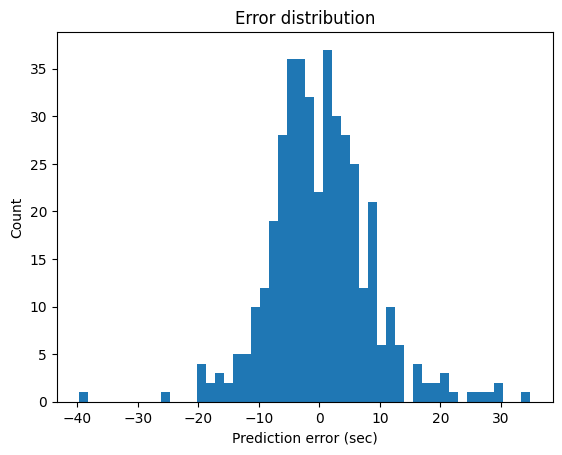

In [3]:
plot_correlation("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_CNN8_pred_intervals.csv", 
                 "Estimated vs True Time (CNN8 estimator)")


Pearson r: 0.713
p-value: 3.687004997171613e-65
Spearman r: 0.712
p-value: 1.0768706093352456e-64


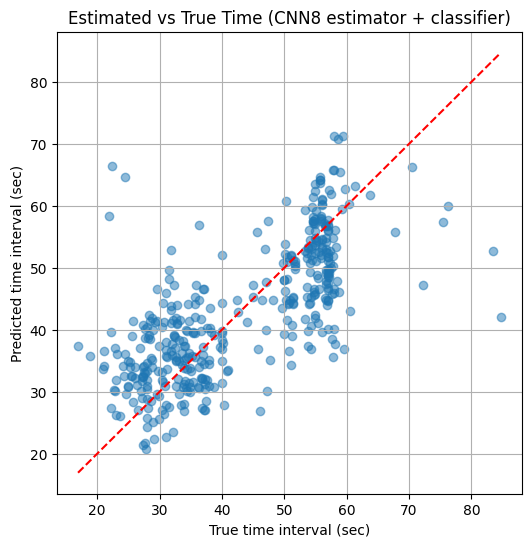

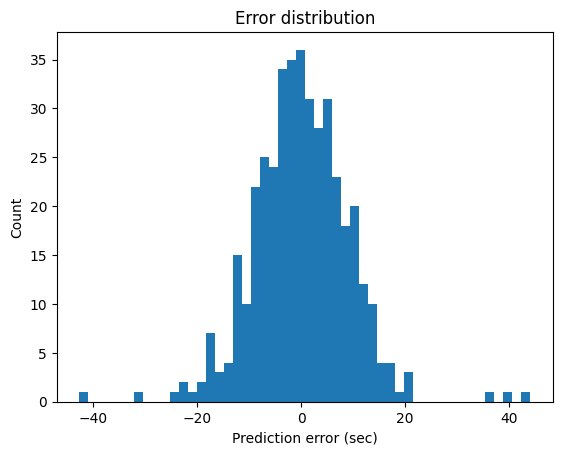

In [4]:
plot_correlation("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_with_Classifier_CNN8_pred_intervals.csv", 
                 "Estimated vs True Time (CNN8 estimator + classifier)")

Pearson r: 0.355
p-value: 1.171237497848229e-13
Spearman r: 0.367
p-value: 1.5997176868580823e-14


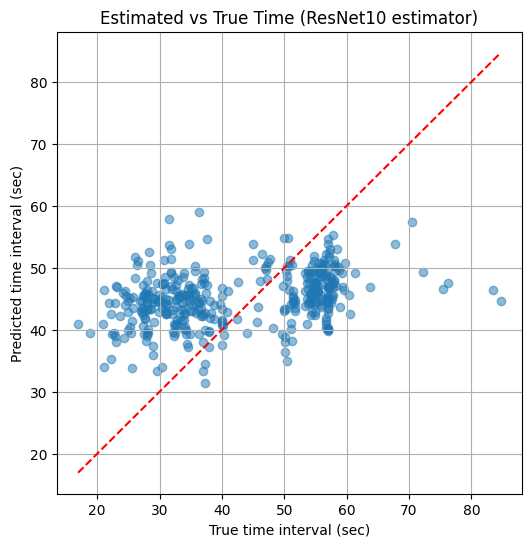

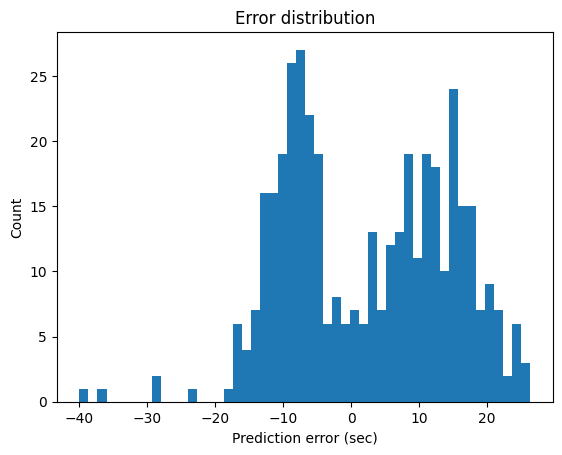

In [5]:
results = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_ResNet10_pred_intervals.csv")
plot_correlation("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_ResNet10_pred_intervals.csv", 
                 "Estimated vs True Time (ResNet10 estimator)")

Pearson r: 0.422
p-value: 3.3484640396679163e-19
Spearman r: 0.463
p-value: 3.170342605319286e-23


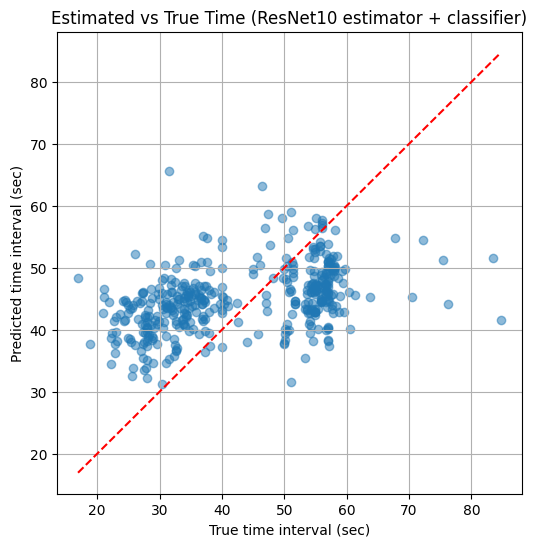

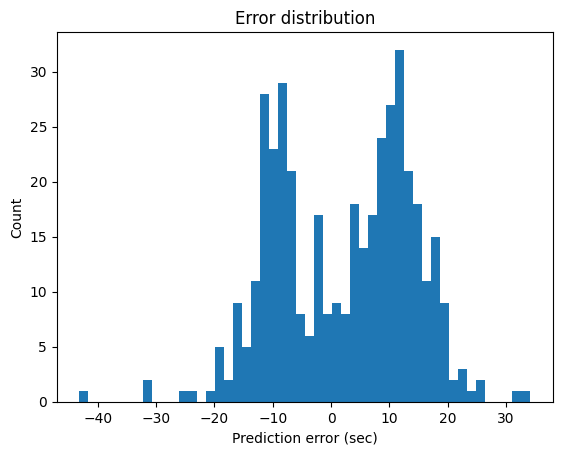

In [6]:
results = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_with_Classifier_ResNet10_pred_intervals.csv")
plot_correlation("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_with_Classifier_ResNet10_pred_intervals.csv", 
                 "Estimated vs True Time (ResNet10 estimator + classifier)")

### DeepTimeRegressor

Pearson r: 0.792
p-value: 1.607223834393462e-89
Spearman r: 0.77
p-value: 8.925278895379516e-82


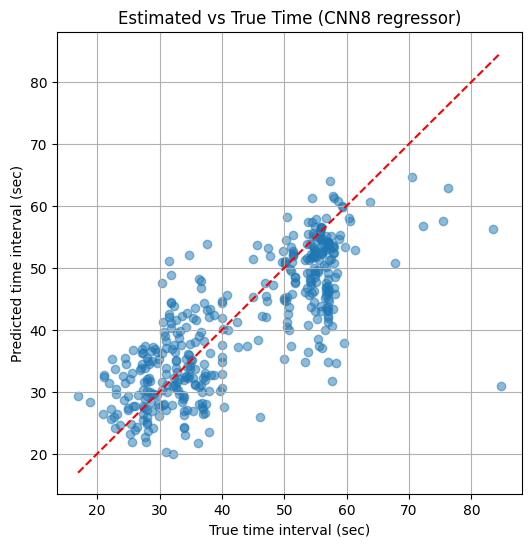

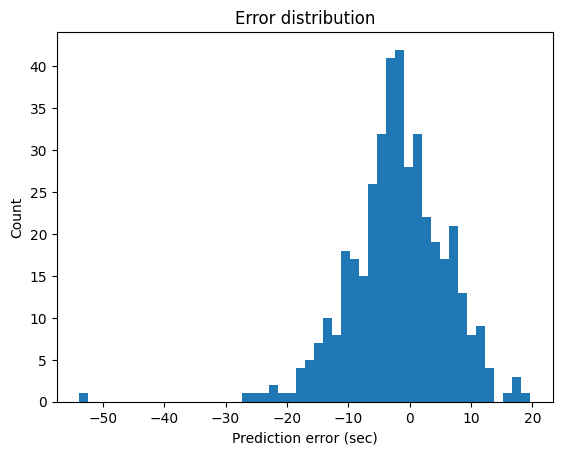

In [11]:
plot_correlation("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeRegressor_CNN8_pred_intervals.csv", 
                 "Estimated vs True Time (CNN8 regressor)")

Pearson r: 0.58
p-value: 2.2297786775328392e-38
Spearman r: 0.582
p-value: 1.2761219589034822e-38


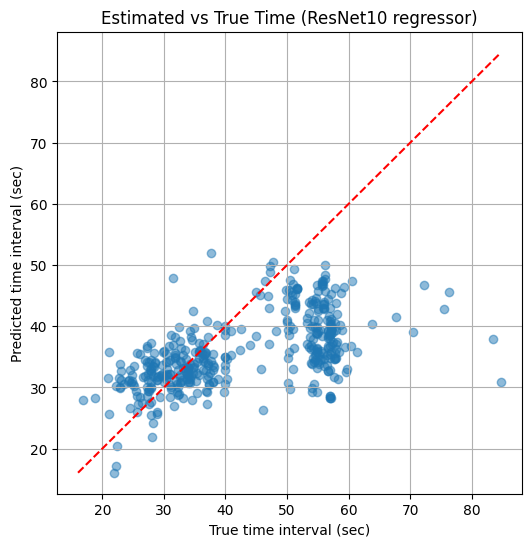

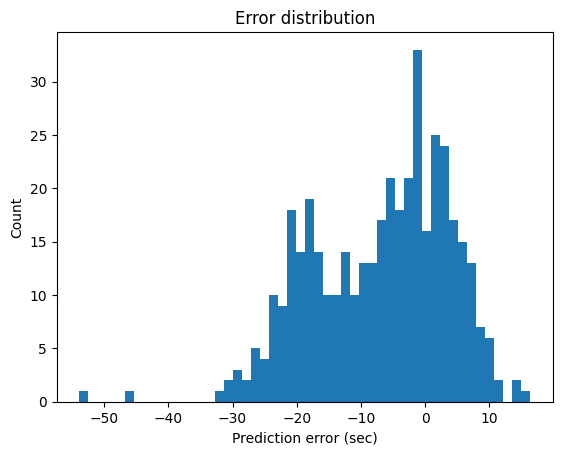

In [12]:
plot_correlation("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeRegressor_ResNet10_pred_intervals.csv",
                 "Estimated vs True Time (ResNet10 regressor)")

# Sigmoid to Real Time Correlation

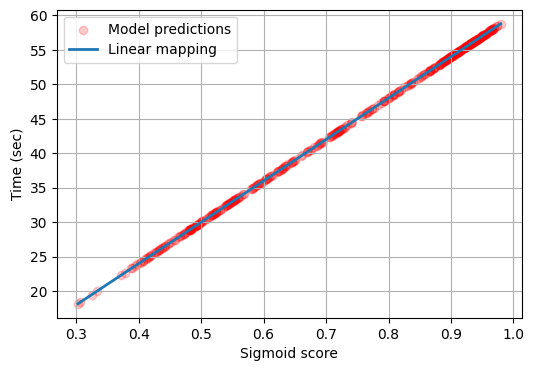

In [ ]:
results = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_CNN8_pred_intervals.csv")
sigmoid = results["sigmoid_scores"].tolist()
pred_times = results["pred_interval"].tolist()

sigmoid = np.array(sigmoid)
true_times = np.array(true_times)
pred_times = np.array(pred_times)
idx = np.argsort(sigmoid)


t_min, t_max = 0, 60

theoretical_time = sigmoid * (t_max - t_min) + t_min

idx = np.argsort(sigmoid)

plt.figure(figsize=(6, 4))
plt.scatter(sigmoid, pred_times, alpha=0.2, label="Model predictions", color="red")
plt.plot(
    sigmoid[idx],
    theoretical_time[idx],
    linewidth=2,
    label="Linear mapping"
)

plt.xlabel("Sigmoid score")
plt.ylabel("Time (sec)")
plt.legend()
plt.grid(True)
plt.show()

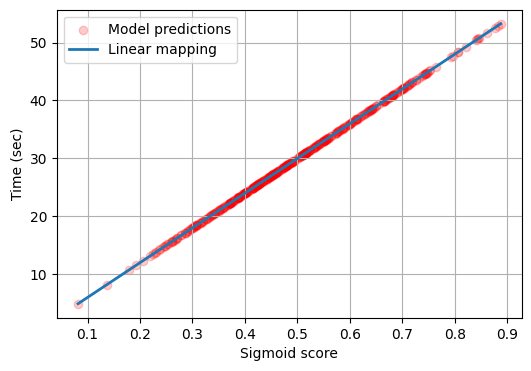

In [22]:
results = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Time_interval/results/DeepTimeEstimator_ResNet10_pred_intervals.csv")
sigmoid = results["sigmoid_scores"].tolist()
pred_times = results["pred_interval"].tolist()

sigmoid = np.array(sigmoid)
true_times = np.array(true_times)
pred_times = np.array(pred_times)
idx = np.argsort(sigmoid)


t_min, t_max = 0, 60

theoretical_time = sigmoid * (t_max - t_min) + t_min

idx = np.argsort(sigmoid)

plt.figure(figsize=(6, 4))
plt.scatter(sigmoid, pred_times, alpha=0.2, label="Model predictions", color="red")
plt.plot(
    sigmoid[idx],
    theoretical_time[idx],
    linewidth=2,
    label="Linear mapping"
)

plt.xlabel("Sigmoid score")
plt.ylabel("Time (sec)")
plt.legend()
plt.grid(True)
plt.show()